In [1]:
# ============================================================
# CELL 1 – Install & Imports
# ============================================================
!pip install tensorflow opencv-python tqdm scikit-learn matplotlib seaborn mtcnn librosa -q

import os, glob
import numpy as np
import cv2
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils import class_weight
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import (
    Input, GlobalAveragePooling2D, Bidirectional, GRU,
    Dropout, Dense, BatchNormalization, Conv2D, MaxPooling2D,
    SeparableConv2D
)
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from mtcnn import MTCNN
print("✅ All imports done")

✅ All imports done


In [9]:
# ============================================================
# CELL 2 – Config
# ============================================================

# ── Video paths (FaceForensics++) ─────────────────────────────
REAL_VIDEO_PATH = "/kaggle/input/faceforensics/FF++/real"
FAKE_VIDEO_PATH = "/kaggle/input/faceforensics/FF++/fake"

# ── Audio paths (Fake-or-Real dataset) – FIXED PATH ──────────
REAL_AUDIO_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/real"
FAKE_AUDIO_PATH = "/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm/for-norm/training/fake"

# ── Hyperparameters ───────────────────────────────────────────
OUTPUT_FRAME_SIZE = (128, 128)
FRAME_COUNT       = 24
MAX_VIDEOS        = 200
MAX_AUDIO         = 500
AUDIO_SAMPLE_RATE = 16000
AUDIO_DURATION    = 5
AUDIO_N_MELS      = 128

detector = MTCNN()
print("✅ Config done")
print("Input datasets:", os.listdir("/kaggle/input"))

✅ Config done
Input datasets: ['datasets', 'faceforensics']


In [3]:
# ============================================================
# CELL 3 – Video Feature Extraction
# ============================================================

def extract_face(frame):
    try:
        results = detector.detect_faces(frame)
        if results:
            x, y, w, h = results[0]['box']
            x, y = max(0, x), max(0, y)
            if w > 0 and h > 0:
                face = frame[y:y+h, x:x+w]
                if face.size > 0:
                    return cv2.resize(face, OUTPUT_FRAME_SIZE)
    except Exception:
        pass
    return cv2.resize(frame, OUTPUT_FRAME_SIZE)

def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return np.array([])
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(total_frames // FRAME_COUNT, 1)
    for i in range(FRAME_COUNT):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i * step)
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(extract_face(frame))
    cap.release()
    return np.array(frames)

video_data, video_labels = [], []
real_videos = os.listdir(REAL_VIDEO_PATH)[:MAX_VIDEOS]
fake_videos = os.listdir(FAKE_VIDEO_PATH)[:MAX_VIDEOS]

print("Processing real videos...")
for vf in tqdm(real_videos):
    frames = extract_frames(os.path.join(REAL_VIDEO_PATH, vf))
    if len(frames) == FRAME_COUNT:
        video_data.append(frames)
        video_labels.append(0)

print("Processing fake videos...")
for vf in tqdm(fake_videos):
    frames = extract_frames(os.path.join(FAKE_VIDEO_PATH, vf))
    if len(frames) == FRAME_COUNT:
        video_data.append(frames)
        video_labels.append(1)

video_data   = np.array(video_data, dtype=np.float32) / 255.0
video_labels = np.array(video_labels)
print(f"✅ Video data: {video_data.shape}")
print(f"   Real: {np.sum(video_labels==0)}, Fake: {np.sum(video_labels==1)}")

Processing real videos...


100%|██████████| 200/200 [2:26:46<00:00, 44.03s/it]  


Processing fake videos...


100%|██████████| 200/200 [2:14:01<00:00, 40.21s/it]  


✅ Video data: (400, 24, 128, 128, 3)
   Real: 200, Fake: 200


In [11]:
# ============================================================
# CELL 4 – Audio Feature Extraction
# Using Fake-or-Real (FoR) dataset – thousands of samples
# ============================================================

def extract_mel_spectrogram(audio_path):
    try:
        y, sr = librosa.load(audio_path, sr=AUDIO_SAMPLE_RATE,
                             duration=AUDIO_DURATION)
        # Pad if shorter than AUDIO_DURATION
        target_len = AUDIO_SAMPLE_RATE * AUDIO_DURATION
        if len(y) < target_len:
            y = np.pad(y, (0, target_len - len(y)))
        mel    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=AUDIO_N_MELS)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = cv2.resize(mel_db.astype(np.float32), (AUDIO_N_MELS, AUDIO_N_MELS))
        # Min-max normalise to [0, 1]
        mel_min, mel_max = mel_db.min(), mel_db.max()
        mel_db = (mel_db - mel_min) / (mel_max - mel_min + 1e-8)
        return mel_db
    except Exception as e:
        return None   # skip bad files

audio_data, audio_labels = [], []

# Collect recursively – FoR has nested folders
real_audio_files = (
    glob.glob(os.path.join(REAL_AUDIO_PATH, "**/*.wav"), recursive=True) +
    glob.glob(os.path.join(REAL_AUDIO_PATH, "**/*.mp3"), recursive=True) +
    glob.glob(os.path.join(REAL_AUDIO_PATH, "*.wav"))
)[:MAX_AUDIO]

fake_audio_files = (
    glob.glob(os.path.join(FAKE_AUDIO_PATH, "**/*.wav"), recursive=True) +
    glob.glob(os.path.join(FAKE_AUDIO_PATH, "**/*.mp3"), recursive=True) +
    glob.glob(os.path.join(FAKE_AUDIO_PATH, "*.wav"))
)[:MAX_AUDIO]

print(f"Found {len(real_audio_files)} real, {len(fake_audio_files)} fake audio files")

print("Processing real audio...")
for af in tqdm(real_audio_files):
    mel = extract_mel_spectrogram(af)
    if mel is not None:
        audio_data.append(mel)
        audio_labels.append(0)

print("Processing fake audio...")
for af in tqdm(fake_audio_files):
    mel = extract_mel_spectrogram(af)
    if mel is not None:
        audio_data.append(mel)
        audio_labels.append(1)

audio_data   = np.expand_dims(np.array(audio_data, dtype=np.float32), -1)
audio_labels = np.array(audio_labels)
print(f"✅ Audio data: {audio_data.shape}")
print(f"   Real: {np.sum(audio_labels==0)}, Fake: {np.sum(audio_labels==1)}")

Found 500 real, 500 fake audio files
Processing real audio...


100%|██████████| 500/500 [00:26<00:00, 19.18it/s]


Processing fake audio...


100%|██████████| 500/500 [00:12<00:00, 40.87it/s]

✅ Audio data: (1000, 128, 128, 1)
   Real: 500, Fake: 500


In [12]:
# ============================================================
# CELL 5 – Train / Val / Test Splits
# Video and Audio are split independently (different datasets)
# ============================================================

# Video split
(X_train_vid, X_temp_vid, y_train_vid, y_temp_vid) = train_test_split(
    video_data, video_labels, test_size=0.3, random_state=42, stratify=video_labels)
(X_val_vid, X_test_vid, y_val_vid, y_test_vid) = train_test_split(
    X_temp_vid, y_temp_vid, test_size=0.5, random_state=42, stratify=y_temp_vid)

# Audio split
(X_train_aud, X_temp_aud, y_train_aud, y_temp_aud) = train_test_split(
    audio_data, audio_labels, test_size=0.3, random_state=42, stratify=audio_labels)
(X_val_aud, X_test_aud, y_val_aud, y_test_aud) = train_test_split(
    X_temp_aud, y_temp_aud, test_size=0.5, random_state=42, stratify=y_temp_aud)

# One-hot encode
y_train_vid_cat = to_categorical(y_train_vid, 2)
y_val_vid_cat   = to_categorical(y_val_vid,   2)
y_test_vid_cat  = to_categorical(y_test_vid,  2)
y_train_aud_cat = to_categorical(y_train_aud, 2)
y_val_aud_cat   = to_categorical(y_val_aud,   2)
y_test_aud_cat  = to_categorical(y_test_aud,  2)

print(f"Video  – train: {X_train_vid.shape} | val: {X_val_vid.shape} | test: {X_test_vid.shape}")
print(f"Audio  – train: {X_train_aud.shape} | val: {X_val_aud.shape} | test: {X_test_aud.shape}")

Video  – train: (280, 24, 128, 128, 3) | val: (60, 24, 128, 128, 3) | test: (60, 24, 128, 128, 3)
Audio  – train: (700, 128, 128, 1) | val: (150, 128, 128, 1) | test: (150, 128, 128, 1)


In [13]:
# ============================================================
# CELL 6 – Model Definitions
# ============================================================

def build_video_model():
    video_input = Input(shape=(FRAME_COUNT, 128, 128, 3), name="video_input")

    base_cnn = Xception(weights='imagenet', include_top=False,
                        input_shape=(128, 128, 3), pooling='avg')
    for layer in base_cnn.layers[:-30]:
        layer.trainable = False

    def apply_cnn_to_frames(inputs):
        B      = tf.shape(inputs)[0]
        frames = tf.reshape(inputs, (B * FRAME_COUNT, 128, 128, 3))
        frames = xception_preprocess(frames * 255.0)
        feats  = base_cnn(frames, training=False)
        return tf.reshape(feats, (B, FRAME_COUNT, feats.shape[-1]))

    x = tf.keras.layers.Lambda(apply_cnn_to_frames, name="xception_timedist")(video_input)
    x = BatchNormalization(name="bn_temporal")(x)
    x = Bidirectional(GRU(128, return_sequences=False,
                          kernel_regularizer=l2(0.005),
                          recurrent_regularizer=l2(0.001)), name="bigru")(x)
    x = Dropout(0.5, name="drop_vid")(x)
    x = Dense(64, activation='relu', name="fc_vid")(x)
    x = Dropout(0.4, name="drop_vid2")(x)
    output = Dense(2, activation='softmax', name="out_vid")(x)
    return Model(inputs=video_input, outputs=output, name="video_model")


def build_audio_model():
    audio_input = Input(shape=(128, 128, 1), name="audio_input")

    # Block 1
    x = Conv2D(32, (3,3), activation='relu', padding='same')(audio_input)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    # Block 2
    x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    # Block 3
    x = SeparableConv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = SeparableConv2D(128, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.25)(x)
    # Block 4
    x = SeparableConv2D(256, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(2, activation='softmax', name="out_aud")(x)
    return Model(inputs=audio_input, outputs=output, name="audio_model")


video_model = build_video_model()
audio_model = build_audio_model()

video_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                    loss='categorical_crossentropy', metrics=['accuracy'])
audio_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                    loss='categorical_crossentropy', metrics=['accuracy'])

print("✅ Video model:")
video_model.summary()
print("\n✅ Audio model:")
audio_model.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Video model:


Model: "video_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 24, 128, 128,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception_timedist (Lambda)      │ (None, 24, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_temporal                     │ (None, 24, 2048)       │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bigru (Bidirectional)           │ (None, 256)            │     1,672,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_vid (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_vid (Dense)                  │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_vid2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out_vid (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697,474 (6.48 MB)

 Trainable params: 1,693,378 (6.46 MB)

...

Model: "audio_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ audio_input (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 64, 64, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 64)     │         4,736 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 32, 32, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_4              │ (None, 16, 16, 256)    │        34,17

 Total params: 163,650 (639.26 KB)

 Trainable params: 161,730 (631.76 KB)

 Non-trainable params: 1,920 (7.50 KB)

Video class weights: {0: 1.0, 1: 1.0}
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.5140 - loss: 7.4629
Epoch 1: val_accuracy improved from -inf to 0.63333, saving model to best_video_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 29s 492ms/step - accuracy: 0.5145 - loss: 7.4608 - val_accuracy: 0.6333 - val_loss: 7.0403 - learning_rate: 1.0000e-04
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.6817 - loss: 6.9999
Epoch 2: val_accuracy improved from 0.63333 to 0.66667, saving model to best_video_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 403ms/step - accuracy: 0.6814 - loss: 6.9978 - val_accuracy: 0.6667 - val_loss: 6.7467 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.8070 - loss: 6.5445
Epoch 3: val_accuracy did not improve from 0.66667
35/35 ━━━━━━━━━━━━━━━━━━━━ 14s 407ms/step - accuracy: 0.8057 - loss: 6.5450 - val_accuracy: 0.6500 - val_loss: 6.4919 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━

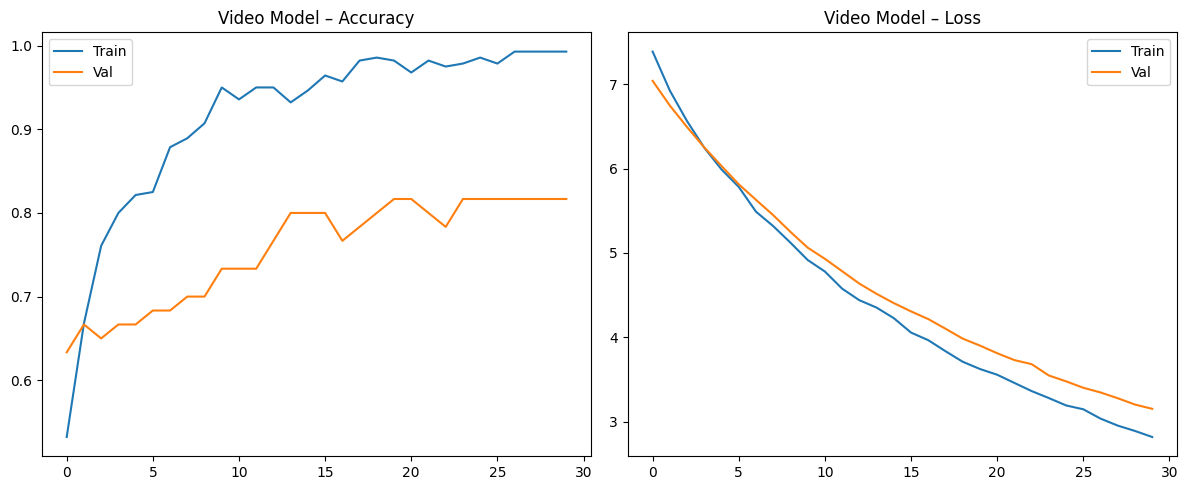

2/2 ━━━━━━━━━━━━━━━━━━━━ 29s 14s/step


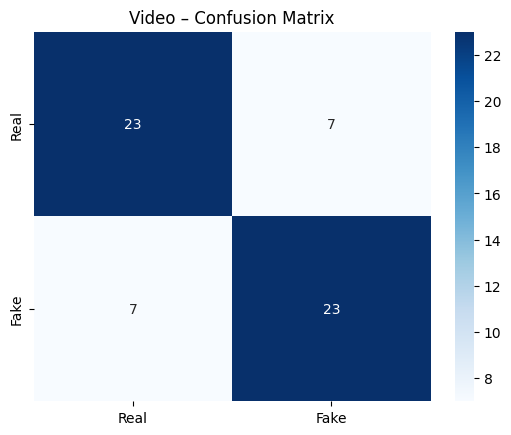

              precision    recall  f1-score   support

        Real       0.77      0.77      0.77        30
        Fake       0.77      0.77      0.77        30

    accuracy                           0.77        60
   macro avg       0.77      0.77      0.77        60
weighted avg       0.77      0.77      0.77        60



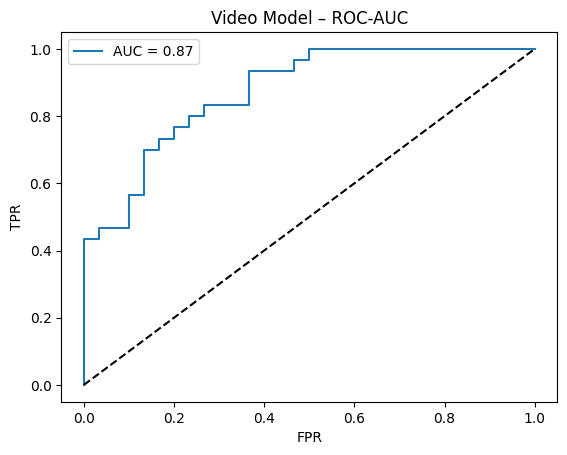

✅ best_video_model.keras saved


In [14]:
# ============================================================
# CELL 7 – Train Video Model
# ============================================================

cw_vid_arr = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_vid), y=y_train_vid)
cw_vid = {0: cw_vid_arr[0], 1: cw_vid_arr[1]}
print("Video class weights:", cw_vid)

callbacks_vid = [
    ModelCheckpoint("best_video_model.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1),
    EarlyStopping(monitor="val_accuracy", patience=10,
                  restore_best_weights=True, verbose=1)
]

history_vid = video_model.fit(
    X_train_vid, y_train_vid_cat,
    validation_data=(X_val_vid, y_val_vid_cat),
    epochs=50, batch_size=8,
    class_weight=cw_vid, callbacks=callbacks_vid
)

# ── Plots ─────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history_vid.history['accuracy'],     label='Train')
plt.plot(history_vid.history['val_accuracy'], label='Val')
plt.legend(); plt.title('Video Model – Accuracy')
plt.subplot(1,2,2)
plt.plot(history_vid.history['loss'],     label='Train')
plt.plot(history_vid.history['val_loss'], label='Val')
plt.legend(); plt.title('Video Model – Loss')
plt.tight_layout(); plt.show()

# ── Evaluation ────────────────────────────────────────────────
y_pred_vid     = video_model.predict(X_test_vid)
y_pred_vid_cls = np.argmax(y_pred_vid, axis=1)

cm = confusion_matrix(y_test_vid, y_pred_vid_cls)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.title("Video – Confusion Matrix"); plt.show()

print(classification_report(y_test_vid, y_pred_vid_cls,
                             target_names=["Real","Fake"]))

fpr, tpr, _ = roc_curve(y_test_vid, y_pred_vid[:, 1])
auc = roc_auc_score(y_test_vid, y_pred_vid[:, 1])
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Video Model – ROC-AUC"); plt.legend(); plt.show()
print(f"✅ best_video_model.keras saved")

Augmenting training data...
Training samples after augmentation: 1400
Audio class weights: {0: 1.0, 1: 1.0}
Epoch 1/80


I0000 00:00:1782545135.719799     109 service.cc:145] XLA service 0x7ca9500f3c90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782545135.719868     109 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782545135.719878     109 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 5/88 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.6340 - loss: 0.9838

I0000 00:00:1782545150.560869     109 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.7667 - loss: 0.6581
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_audio_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.7671 - loss: 0.6566 - val_accuracy: 0.5000 - val_loss: 0.7201 - learning_rate: 0.0010
Epoch 2/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8456 - loss: 0.4052
Epoch 2: val_accuracy did not improve from 0.50000
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8456 - loss: 0.4049 - val_accuracy: 0.5000 - val_loss: 0.7005 - learning_rate: 0.0010
Epoch 3/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8559 - loss: 0.3711
Epoch 3: val_accuracy did not improve from 0.50000
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8558 - loss: 0.3710 - val_accuracy: 0.5000 - val_loss: 0.7485 - learning_rate: 0.0010
Epoch 4/80
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8646 - loss: 0.3104
Epoch 4: val_accuracy did not improve from 0.50000
88/

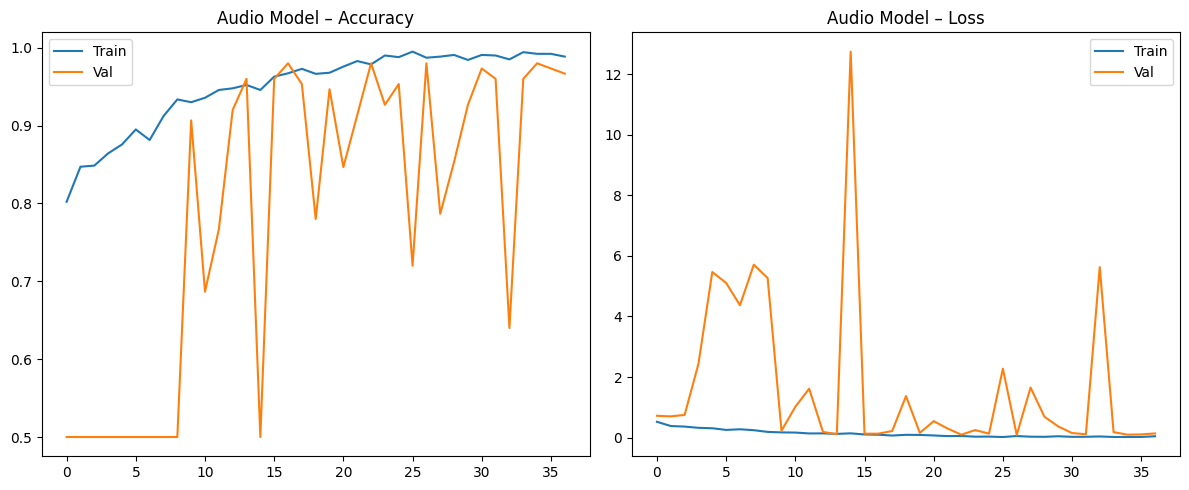

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 473ms/step


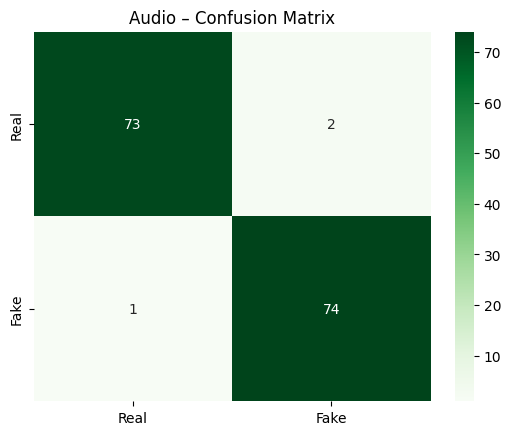

              precision    recall  f1-score   support

        Real       0.99      0.97      0.98        75
        Fake       0.97      0.99      0.98        75

    accuracy                           0.98       150
   macro avg       0.98      0.98      0.98       150
weighted avg       0.98      0.98      0.98       150



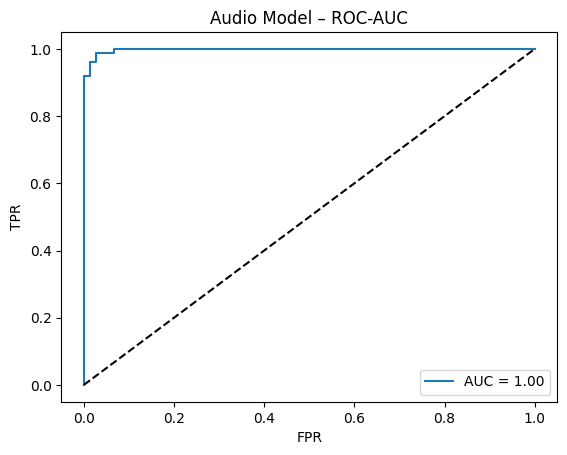

✅ best_audio_model.keras saved


In [15]:
# ============================================================
# CELL 8 – Train Audio Model
# Improved: deeper CNN + SpecAugment + more epochs
# ============================================================

# ── SpecAugment data augmentation ─────────────────────────────
def augment_mel(mel):
    mel = mel.copy()
    t = np.random.randint(0, 20)
    t0 = np.random.randint(0, max(1, 128 - t))
    mel[t0:t0+t, :, :] = 0
    f = np.random.randint(0, 15)
    f0 = np.random.randint(0, max(1, 128 - f))
    mel[:, f0:f0+f, :] = 0
    return mel

print("Augmenting training data...")
X_train_aug      = np.array([augment_mel(x) for x in X_train_aud])
X_train_combined = np.concatenate([X_train_aud, X_train_aug], axis=0)
y_train_combined = np.concatenate([y_train_aud_cat, y_train_aud_cat], axis=0)
print(f"Training samples after augmentation: {len(X_train_combined)}")

cw_aud_arr = class_weight.compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train_aud), y=y_train_aud)
cw_aud = {0: cw_aud_arr[0], 1: cw_aud_arr[1]}
print("Audio class weights:", cw_aud)

callbacks_aud = [
    ModelCheckpoint("best_audio_model.keras", monitor="val_accuracy",
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5,
                      verbose=1, min_lr=1e-6),
    EarlyStopping(monitor="val_accuracy", patience=20,
                  restore_best_weights=True, verbose=1)
]

history_aud = audio_model.fit(
    X_train_combined, y_train_combined,
    validation_data=(X_val_aud, y_val_aud_cat),
    epochs=80, batch_size=16,
    class_weight=cw_aud, callbacks=callbacks_aud, shuffle=True
)

# ── Plots ─────────────────────────────────────────────────────
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.plot(history_aud.history['accuracy'],     label='Train')
plt.plot(history_aud.history['val_accuracy'], label='Val')
plt.legend(); plt.title('Audio Model – Accuracy')
plt.subplot(1,2,2)
plt.plot(history_aud.history['loss'],     label='Train')
plt.plot(history_aud.history['val_loss'], label='Val')
plt.legend(); plt.title('Audio Model – Loss')
plt.tight_layout(); plt.show()

# ── Evaluation ────────────────────────────────────────────────
y_pred_aud     = audio_model.predict(X_test_aud)
y_pred_aud_cls = np.argmax(y_pred_aud, axis=1)

cm_aud = confusion_matrix(y_test_aud, y_pred_aud_cls)
sns.heatmap(cm_aud, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"])
plt.title("Audio – Confusion Matrix"); plt.show()

print(classification_report(y_test_aud, y_pred_aud_cls,
                             target_names=["Real","Fake"], zero_division=0))

if len(np.unique(y_test_aud)) > 1:
    fpr_a, tpr_a, _ = roc_curve(y_test_aud, y_pred_aud[:, 1])
    auc_a = roc_auc_score(y_test_aud, y_pred_aud[:, 1])
    plt.figure()
    plt.plot(fpr_a, tpr_a, label=f"AUC = {auc_a:.2f}")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.title("Audio Model – ROC-AUC"); plt.legend(); plt.show()
else:
    print("(Only one class in test set – ROC-AUC skipped)")

print(f"✅ best_audio_model.keras saved")